Previously, we have slightly touched on the topic of regularization. Now, this example script provides a comprehensive discussion.

In [ ]:
# basic imports and setting JAX options
import numpy as np
from jax import numpy as jnp
import jax
from matplotlib import pyplot as plt
from model_augmentation_jax import GeneralNonlinearSystem, StaticLFRAugmentation
from model_augmentation_jax.utils import compute_normalization_constants


jax.config.update('jax_platform_name', 'cpu')
if not jax.config.jax_enable_x64:
    jax.config.update("jax_enable_x64", True)  # Enable 64-bit computations

# Generate or load data
np.random.seed(0)
U = np.random.normal(size=10_000) # Input sequence
x = [0, 0] # Initial state
ylist = [] # Output sequence
for uk in U:
    ylist.append(x[0] + np.random.normal(loc=0., scale=0.01))  # Compute output
    x = 0.9 * x[0] + 0.1 * x[1] + 0.1 * uk + 0.02 * x[0] * x[1], \
       -0.2 * x[0] + 0.95 * x[1] + 0.05 * uk - 0.1 * x[0]**3 # Advance state

# Split dataset
Y = np.array(ylist)
Y_train = Y[:9000]
Y_test = Y[9000:]
U_train = U[:9000]
U_test = U[9000:]

# create nonlinear baseline model
class nonlinear_baseline_model(GeneralNonlinearSystem):
    def __init__(self, init_params, tune_params):
        # for nonlinear baseline models, there is an option to co-estimate the physical parameters with the
        # learning-based ones
        super().__init__(nx=2, ny=1, nu=1, params=init_params, tune_params=tune_params)

    def f(self, x, u, params):
        # with nonlinear abseline models, the state transition function and output maps must be implemented manually
        x1_plus = params[0] * x[0] + params[1] * x[1] + params[2] * u[0]
        x2_plus = -params[3] * x[0] + params[4] * x[1] - params[5] * x[0]**3
        return jnp.array([x1_plus, x2_plus])

    def h(self, x, u, params):
        return x[0:1]

# create baseline model (with approximate params)
init_baseline_params = np.array([0.8, 0.15, 0.12, 0.18, 0.9, 0.08])
fp_model = nonlinear_baseline_model(init_params=init_baseline_params, tune_params=True)  # also indicate whether to tune the baseline parameters

# simulate baseline model to approximate constants for normalization
Yhat_train_base, Xhat_train_base = fp_model.simulate(U_train)  # starts from x0 = 0
norm = compute_normalization_constants(U_train, Y_train, Xhat_train_base)

Regularization options can be added after initializing the model by calling the `model.set_regularization_terms` function. By overwriting the default arguments, the following options are available:
- `rho_base`: Regularization coefficient to penalize tuning of the baseline parameters compared to their nominal values. This is only useful when the baseline parameters are co-estimated with the learning component. See, e.g., example 1.
- `rho_aug`: $\ell_2$ regularization coefficient on the ANN parameters.
- `tau_aug`:  $\ell_2$ regularization coefficient on the ANN parameters.
- `rho_x0`: $\ell_2$ regularization on the initial states. Useful when $x_0$ is co-estimated with tha parameters, i.e., when the initial states corresponding to the training set are not known. It is useful to apply at least with a small coefficient, e.g., $10^4$.
- `tau_lfr` and `lfr_reg_coeffs`: These values are associated with the (re-weighted) $\ell_1$ regularization scheme on the LFR matrix, which can be used for automatic moel structure discovery. For more details, see the folder `examples/iterative_l1_reg_example/`.
- `tau_z`, `tau_w`, and `tau_x`: These coefficient sare associated with group-lasso regularization to detect and discard redundant dimensions in latent variables. For more details, see the folder `examples/group_lasso_example/`.
- `ann_lipschitz_regul_coeff`: Regularization coefficient for the ANN Lipschitz bound. Useful (or rather necessary) for the well-posed and contracting augmentation structures.

In this example, first, we provide a sweep for the `rho_base` coefficient, then for the `tau_aug` coefficient to demonstrate their effects.

# Baseline parameter regularization

In [ ]:
rho_base_list = [1e-4, 1e-3, 1e-2, 1e-1, 1.]
rho_base_dev_list = []

for rb in rho_base_list:
    # create augmented model
    model = StaticLFRAugmentation(known_sys=fp_model, hidden_layers=2, nodes_per_layer=8, activation="tanh", nz=2, nw=2,
                              norm_dict=norm)
    # set training options
    model.set_optimization_parameters(adam_epochs=100, lbfgs_epochs=500, train_x0=True, verbosity=0)

    # set baseline regularization
    model.set_regularization_terms(rho_base=rb)

    # train the model
    model.fit(Y_train, U_train)

    # get tuned baseline parameters and evaluate difference from initial params.
    tuned_baseline_params = model.get_physical_params(model.params)
    rho_base_dev_list.append(np.linalg.norm(init_baseline_params - tuned_baseline_params, 2))

As visible, increasing `rho_base` enables smaller and smaller deviations of the baseline parameters compared to their initial values, while a smaller `rho_base` value enables $\theta_\mathrm{b}$ to be tuned more freely.

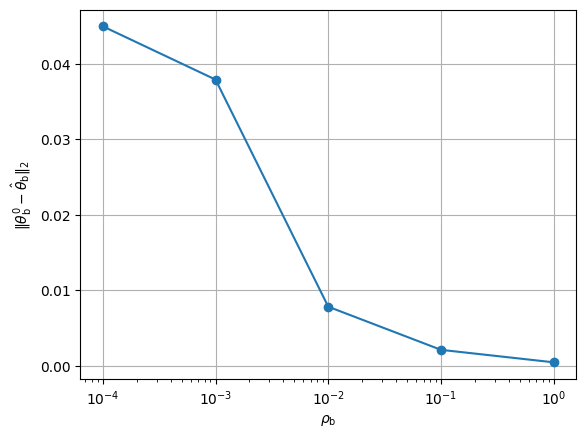

In [3]:
plt.figure()
plt.semilogx(rho_base_list, rho_base_dev_list, '-o')
plt.xlabel(r"$\rho_\mathrm{b}$")
plt.ylabel(r"$\|\theta_\mathrm{b}^0 - \hat{\theta}_\mathrm{b}\|_2$")
plt.grid()
plt.show()

# ANN $\ell_1$ regularization
Now, we repeat the experiment with `tau_aug` and report the percentage of zero parameters in the ANN. We can set the `zero_coeff` argument in the `set_optimization_parameters` function to provide a boundary for thresholding. Parameters in the ANN with an absolute value smaller that `zero_coeff` are viewed as zeros. We set this threshold to $10^{-4}$ in this example.

In [ ]:
tau_aug_list = [1e-4, 1e-3, 1e-2, 1e-1, 1.]
zero_param_prcntg_list = []

for ta in tau_aug_list:
    # create augmented model
    model = StaticLFRAugmentation(known_sys=fp_model, hidden_layers=2, nodes_per_layer=8, activation="tanh", nz=2, nw=2,
                              norm_dict=norm)
    # set training options
    model.set_optimization_parameters(adam_epochs=100, lbfgs_epochs=500, train_x0=True, verbosity=0, zero_coeff=1e-4)

    # set baseline regularization
    model.set_regularization_terms(tau_aug=ta)

    # train the model
    model.fit(Y_train, U_train)

    n_zeros, n_all = model.count_ann_zero_params()
    zero_param_prcntg_list.append(n_zeros / n_all)

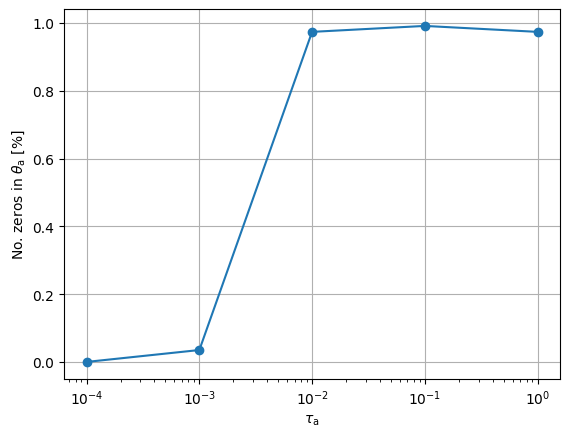

In [5]:
plt.figure()
plt.semilogx(tau_aug_list, zero_param_prcntg_list, '-o')
plt.xlabel(r"$\tau_\mathrm{a}$")
plt.ylabel(r"No. zeros in $\theta_\mathrm{a}$ [%]")
plt.grid()
plt.show()